In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st

In [2]:
# Выгружаем разные листы из файла, каждый лист в отдельный датафоейм
payments = pd.read_excel('dataset.xlsx', sheet_name = 0)
clients = pd.read_excel('dataset.xlsx', sheet_name = 1)
region_dict = pd.read_excel('dataset.xlsx', sheet_name = 2)

### Рассмотрим все таблицы на предмет пустых ячеек.

In [3]:
payments.head()

,id_order,id_client,amt_payment,dtime_pay
0,100238,194569.0,5373.0,2022-10-28 04:05:15.221
1,100242,191056.0,4151.0,2022-08-01 02:42:54.992
2,100249,200049.0,5688.0,2022-08-24 12:45:12.744
3,100258,206161.0,4330.0,2022-12-09 15:13:26.437
4,100267,190945.0,5488.0,2022-08-03 02:07:31.468


In [4]:
payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37989 entries, 0 to 37988
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id_order     37989 non-null  int64         
 1   id_client    37401 non-null  float64       
 2   amt_payment  35845 non-null  float64       
 3   dtime_pay    35560 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1)
memory usage: 1.2 MB


In [5]:
from IPython.display import Markdown, display

share_nan_p = len(payments[payments.isna().any(axis=1)]) / len(payments)
cnt_null = len(payments[payments.isna().any(axis=1)])

text_p = f"""
#### Доля строк, где есть хотя бы одно пустое значение в датафрейме payments {share_nan_p:.2%}, всего таких строк {cnt_null}
"""

display(Markdown(text_p))



#### Доля строк, где есть хотя бы одно пустое значение в датафрейме payments 6.39%, всего таких строк 2429


#### Можем подробнее рассмотреть сколько пустых значений в каждом столбце, чтобы решить, что точно делать с такими значениями. 

In [6]:
payments.isna().mean()

id_order       0.000000
id_client      0.015478
amt_payment    0.056437
dtime_pay      0.063940
dtype: float64

#### Видим, что процент строк, где есть хотя бы одно пустое значение, совпадает с процетом пустых строк в столбце dtime_pay. Можем сделать вывод, что это не просто случайно незаполненные ячейки, а именно незавершенные заказы. Значит мы не должны их учитывать в своем анализе, поскольку мы исследуем метрику "Конверсия из рекламы в покупку".

In [7]:
payments_clean = payments.loc[~payments['dtime_pay'].isna()] 

#### Посмотрим на записи, которые мы решили не учитывать. Возможно в них есть закономерности.

In [8]:
p = payments.loc[payments['dtime_pay'].isna()]  

In [9]:
p_c = p.merge(clients, on = 'id_client', how = 'left') # соединим с датафреймом клиентов, чтобы понять в какой группе были пользователи

In [10]:
p_c_1 = p_c.loc[~p_c['dtime_ad'].isna()] # Возьмем только тех клиентов, где мы точно знаем что была показана реклама

In [11]:
p_c_1.groupby('nflag_test').count() # посчитаем сколько пользователей не дошли до оплаты в тестовой, а сколько в контрольной

,id_order,id_client,amt_payment,dtime_pay,dtime_ad,id_trading_point
nflag_test,,,,,,
0.0,550,550,0,0,550,550
1.0,983,983,17,0,983,983


#### Видим, что количество пользователей с пустыми значениями в контрольной группе почти в 2 раза выше. Чтобы сделать какие-то выводы необходимы дополнительные исследования. 

In [12]:
payments_clean.info() # Проверим что действительно не осталось нуллов в каком-либо из столбцов

<class 'pandas.core.frame.DataFrame'>
Index: 35560 entries, 0 to 37988
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id_order     35560 non-null  int64         
 1   id_client    35560 non-null  float64       
 2   amt_payment  35560 non-null  float64       
 3   dtime_pay    35560 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1)
memory usage: 1.4 MB


In [13]:
clients.head()

,id_client,dtime_ad,nflag_test,id_trading_point
0,180844,2022-06-08 18:38:41.414,0,212
1,193942,NaT,0,13
2,226069,2022-07-11 16:28:38.511,1,54
3,183981,2022-06-16 12:23:59.289,1,991
4,322530,2022-07-08 08:56:08.714,0,1015


In [14]:
share_nan_c = len(clients[clients.isna().any(axis=1)]) / len(clients)

text_c = f"""
#### Доля строк, где есть хотя бы одно пустое значение в датафрейме clients {share_nan_c:.2%}
"""
display(Markdown(text_c))


#### Доля строк, где есть хотя бы одно пустое значение в датафрейме clients 0.45%


In [15]:
clients.isna().mean()

id_client           0.000000
dtime_ad            0.004478
nflag_test          0.000000
id_trading_point    0.000000
dtype: float64

#### Все пустые ячейки находятся в колонке dtime_ad, посколку для данных клиентов мы не знаем дату показа рекламы, мы не сможем оценить повлияла ли реклама на их покупку или нет, поэтому не будем учитывать эти данные в своем анализе. 

In [16]:
с = clients.loc[clients['dtime_ad'].isna()]
с.groupby('nflag_test').count() # на всякий случай проверим не возникает ли проблемы с датой в какой-то одной группе

,id_client,dtime_ad,id_trading_point
nflag_test,,,
0,133,0,133
1,116,0,116


#### Видим, что пропуски в дате есть в обоих группах. Будем использовать только те записи, где нет пропущенных значений.

In [17]:
clients_clean = clients.loc[~clients['dtime_ad'].isna()]

In [18]:
clients_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 55356 entries, 0 to 55604
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id_client         55356 non-null  int64         
 1   dtime_ad          55356 non-null  datetime64[ns]
 2   nflag_test        55356 non-null  int64         
 3   id_trading_point  55356 non-null  int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 2.1 MB


#### Проверим наличие дублей, или ошибок, где один и тот же клиент попал в обе группы.

In [19]:
# Если количество уникальных пользователей равно количеству всех пользователей, то можно сделать вывод, что повторений в id нет.
clients_clean['id_client'].nunique() == len(clients_clean)

True

In [20]:
region_dict.head()

,id_trading_point,city
0,1,Петрозаводск
1,2,Дмитров
2,4,Чехов
3,7,Ростов Великий
4,11,Владимир


In [21]:
share_nan_r = len(region_dict[region_dict.isna().any(axis=1)]) / len(region_dict)

text_r = f"""
#### Доля строк, где есть хотя бы одно пустое значение в датафрейме region_dict {share_nan_r:.2%}
#### В данном датафрейме нет пропущенных значений.
"""

display(Markdown(text_r))


#### Доля строк, где есть хотя бы одно пустое значение в датафрейме region_dict 0.00%
#### В данном датафрейме нет пропущенных значений.


In [22]:
# Посмотрим сколько торговых точек в каждом городе
region_dict_gr = region_dict.groupby('city').agg(cnt_points = ('id_trading_point','count')).reset_index().sort_values('cnt_points', ascending = False)

In [23]:
region_dict_gr

,city,cnt_points
7,Москва,11
15,Санкт-Петербург,11
4,Казань,6
10,Новосибирск,6
6,Красноярск,5
14,Самара,4
5,Краснодар,4
16,Саратов,2
18,Сочи,2
8,Мурманск,2


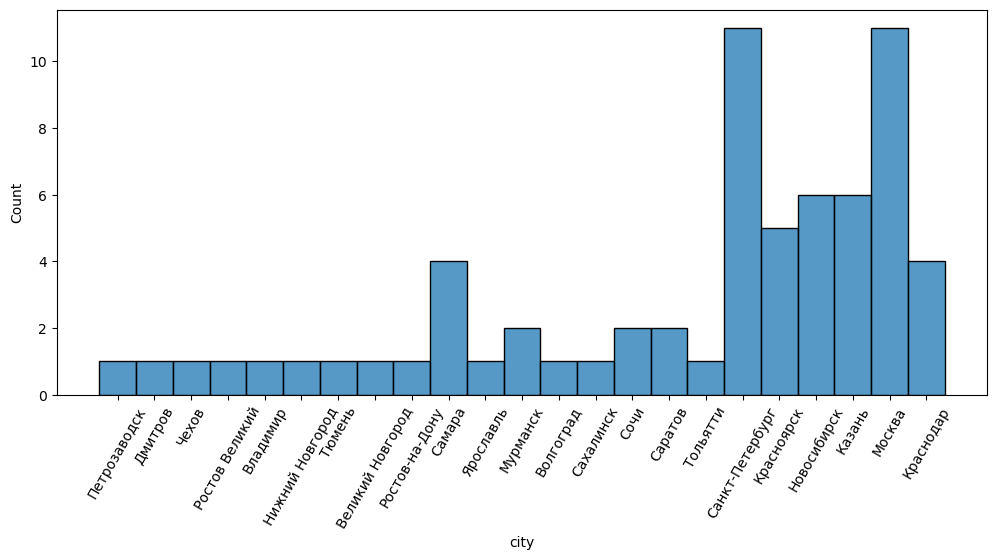

In [24]:
plt.figure(figsize=(12, 5)) 
sns.histplot(region_dict['city'])
plt.xticks(rotation=60)
plt.show()

### Наибольшее количество торговых точек - в Москве и Санкт-Петербурге, далее идут Новосибирск и Казань, следом Красноярск, Краснодар, Самара, по 2 точки в Мурманске, Сочи, Саратове, а в остальных горадах по одной точке. 

## Теперь нужно агрегировать все платежи каждого клиента. Но по скольку мы анализируем именно Конверсию из рекламы в покупку, я предлагаю учитывать только покупки, совершенные после показа пользователю рекламы. 

In [25]:
payments_clients = clients_clean.merge(payments_clean, on = 'id_client', how = 'left')

payments_clients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62533 entries, 0 to 62532
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id_client         62533 non-null  int64         
 1   dtime_ad          62533 non-null  datetime64[ns]
 2   nflag_test        62533 non-null  int64         
 3   id_trading_point  62533 non-null  int64         
 4   id_order          35560 non-null  float64       
 5   amt_payment       35560 non-null  float64       
 6   dtime_pay         35560 non-null  datetime64[ns]
dtypes: datetime64[ns](2), float64(2), int64(3)
memory usage: 3.3 MB


In [26]:
payments_clients.head()

,id_client,dtime_ad,nflag_test,id_trading_point,id_order,amt_payment,dtime_pay
0,180844,2022-06-08 18:38:41.414,0,212,157381.0,5349.0,2022-10-12 00:47:53.057
1,226069,2022-07-11 16:28:38.511,1,54,NaN,NaN,NaT
2,183981,2022-06-16 12:23:59.289,1,991,136901.0,2592.0,2022-10-06 20:20:51.307
3,183981,2022-06-16 12:23:59.289,1,991,168411.0,3730.0,2022-07-18 13:09:51.622
4,322530,2022-07-08 08:56:08.714,0,1015,NaN,NaN,NaT


In [27]:
# проверим есть ли в нашей таблице покупки, совершенные до показа рекламы.
len(payments_clients.loc[payments_clients['dtime_ad'] >= payments_clients['dtime_pay']]) 

0

#### Поскольку в наших данных нет покупок, совершенных до показа рекламы, продолжим работать имеющимся датафреймом.

In [28]:
payments_clients = payments_clients.fillna(0) # заполним пустые ячейки 0 

In [29]:
# Проверим сколько мы в итоге потеряли данных, соеденим исходые таблицы сосчитаем количество строк для неочищенных данных и для очищенных
(len(clients.merge(payments, on = 'id_client', how = 'left'))/len(payments_clients)-1)*100

1.2169574464682587

In [30]:
# агрегируем наш датафрейм по клиентам, чтобы учесть все платежи каждого клиента в одной строке. Найдем сумму всех платежей и среднее для каждого клиента. 
payments_clients_agg = (payments_clients
                        .groupby(['id_client','id_trading_point','nflag_test','dtime_ad'])
                        .agg(amt_all = ('amt_payment','sum'), amt_mean = ('amt_payment','mean'))
                        .reset_index()
                       )

In [31]:
payments_clients_agg.head()

,id_client,id_trading_point,nflag_test,dtime_ad,amt_all,amt_mean
0,178561,453,0,2022-06-03 02:47:49.183,3052.0,3052.0
1,178562,2652,0,2022-06-03 02:51:21.878,2439.0,2439.0
2,178563,112,1,2022-06-03 02:52:10.616,768.0,768.0
3,178564,26,1,2022-06-03 02:53:10.089,0.0,0.0
4,178565,739,1,2022-06-03 02:55:13.525,958.0,958.0


In [32]:
# Проверим нет ли дубликатов
payments_clients_agg['id_client'].nunique() == len(payments_clients_agg)

True

In [33]:
# добавим к таблице и город
ab_clients = payments_clients_agg.merge(region_dict, on = 'id_trading_point', how = 'left')

In [34]:
# добавим флаг была/не была покупка
ab_clients['nflag_paid'] = np.where(ab_clients['amt_all'] != 0,1,0) 

In [35]:
ab_clients

,id_client,id_trading_point,nflag_test,dtime_ad,amt_all,amt_mean,city,nflag_paid
0,178561,453,0,2022-06-03 02:47:49.183,3052.0,3052.0,Санкт-Петербург,1
1,178562,2652,0,2022-06-03 02:51:21.878,2439.0,2439.0,Москва,1
2,178563,112,1,2022-06-03 02:52:10.616,768.0,768.0,Санкт-Петербург,1
3,178564,26,1,2022-06-03 02:53:10.089,0.0,0.0,Ростов-на-Дону,0
4,178565,739,1,2022-06-03 02:55:13.525,958.0,958.0,Новосибирск,1
...,...,...,...,...,...,...,...,...
55351,331949,573,1,2022-07-15 10:07:09.632,0.0,0.0,Санкт-Петербург,0
55352,331950,1654,1,2022-07-18 03:10:18.517,0.0,0.0,Москва,0
55353,331954,544,0,2022-07-08 12:45:17.300,0.0,0.0,Казань,0
55354,331955,72,0,2022-08-12 03:15:49.011,0.0,0.0,Сочи,0


### Созадим функции для вычисления критерия Стьюдента и Манна-Уитни.

In [36]:
def ttest_calc(r1, r2, alpha = 0.05):
    s, p = st.ttest_ind(r1, r2)
    if p <= alpha:
        print(f"t-критерий: {s}, p-value: {p}. Нулевая гипотеза отвергается. Разница среднего в тестовой и контрольной группах статистически ЗНАЧИМА.")
    else: 
        print(f"t- критерий: {s}, p-value: {p}. Нулевая гипотеза НЕ отвергается. Разница среднего в тестовой и контрольной группах статистически НЕ ЗНАЧИМА.")
    return s, p

In [37]:
def mann_whitney_func(r1, r2, alpha = 0.05):
    mw, p = st.mannwhitneyu(r1, r2)
    if p <= alpha:
        print(f"u-критерий: {mw}, p-value: {p}. Нулевая гипотеза отвергается. Разница распределеня в тестовой и контрольной группах статистически ЗНАЧИМА.")
    else: 
        print(f"u-критерий: {mw}, p-value: {p}. Нулевая гипотеза НЕ отвергается. Разница распределеня в тестовой и контрольной группах статистически НЕ ЗНАЧИМА.")
    return mw, p

In [38]:
s_mean, p_mean = ttest_calc(ab_clients[ab_clients['nflag_test'] == 0]['amt_all'], ab_clients[ab_clients['nflag_test'] == 1]['amt_all'])

t-критерий: -6.400366267700368, p-value: 1.5624051059175334e-10. Нулевая гипотеза отвергается. Разница среднего в тестовой и контрольной группах статистически ЗНАЧИМА.


In [39]:
ttest_calc(ab_clients[ab_clients['nflag_test'] == 0]['amt_all'], ab_clients[ab_clients['nflag_test'] == 1]['amt_all'])

t-критерий: -6.400366267700368, p-value: 1.5624051059175334e-10. Нулевая гипотеза отвергается. Разница среднего в тестовой и контрольной группах статистически ЗНАЧИМА.


(np.float64(-6.400366267700368), np.float64(1.5624051059175334e-10))

In [40]:
mann_whitney_func(ab_clients[ab_clients['nflag_test'] == 0]['amt_all'], ab_clients[ab_clients['nflag_test'] == 1]['amt_all'])

u-критерий: 370074960.5, p-value: 5.082016727027916e-10. Нулевая гипотеза отвергается. Разница распределеня в тестовой и контрольной группах статистически ЗНАЧИМА.


(np.float64(370074960.5), np.float64(5.082016727027916e-10))

### Очистим данные от неверно заполненных данных по торговым точкам.
#### Уберем торговые точки, где хотя бы в одной из групп не было заплачено ни рубля.
#### Уберем торговые точки, в которых пустует либо тестовая, либо контрольная группа.

In [41]:
points_wtout_purchases = []
for i in ab_clients['id_trading_point'].unique():
    df_i = ab_clients[ab_clients['id_trading_point'] == i]
    if (df_i[df_i['nflag_test'] == 0]['amt_all'].sum() == 0) or (df_i[df_i['nflag_test'] == 1]['amt_all'].sum() == 0):
        points_wtout_purchases.append(i)
        # print(df_i[df_i['nflag_test'] == 0]['amt_all'].sum(), df_i[df_i['nflag_test'] == 1]['amt_all'].sum())

In [42]:
points_wt_empty_group = []
for i in ab_clients['id_trading_point'].unique():
    df_i = ab_clients[ab_clients['id_trading_point'] == i]
    # print(df_i[df_i['nflag_test'] == 0]['id_client'].count())
    if (df_i[df_i['nflag_test'] == 0]['id_client'].count() == 0) or (df_i[df_i['nflag_test'] == 1]['id_client'].count() == 0):
        points_wt_empty_group.append(i)

In [43]:
ab_clients_clean = (ab_clients.loc[~((ab_clients['id_trading_point'].isin(points_wtout_purchases)) | 
                                     (ab_clients['id_trading_point'].isin(points_wt_empty_group)))
                                  ])

In [44]:
((len(ab_clients_clean)/len(ab_clients))-1) *100



-18.13353566009105

In [45]:
ab_clients_clean

,id_client,id_trading_point,nflag_test,dtime_ad,amt_all,amt_mean,city,nflag_paid
0,178561,453,0,2022-06-03 02:47:49.183,3052.0,3052.000000,Санкт-Петербург,1
1,178562,2652,0,2022-06-03 02:51:21.878,2439.0,2439.000000,Москва,1
2,178563,112,1,2022-06-03 02:52:10.616,768.0,768.000000,Санкт-Петербург,1
6,178567,453,0,2022-06-03 03:02:56.855,2663.0,2663.000000,Санкт-Петербург,1
7,178568,3786,1,2022-06-03 03:05:33.476,13537.0,4512.333333,Москва,1
...,...,...,...,...,...,...,...,...
55351,331949,573,1,2022-07-15 10:07:09.632,0.0,0.000000,Санкт-Петербург,0
55352,331950,1654,1,2022-07-18 03:10:18.517,0.0,0.000000,Москва,0
55353,331954,544,0,2022-07-08 12:45:17.300,0.0,0.000000,Казань,0
55354,331955,72,0,2022-08-12 03:15:49.011,0.0,0.000000,Сочи,0


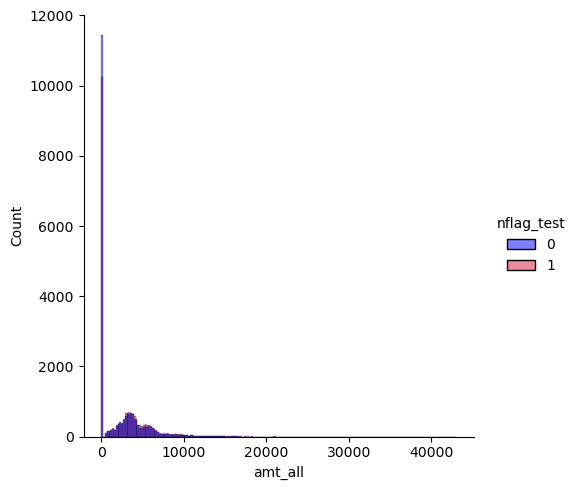

In [46]:
# С помощью гистограммы визуализируем распределение для обоих групп.
sns.displot(ab_clients_clean, x="amt_all", hue="nflag_test", palette={0: "blue", 1: "crimson"})
plt.show()

### На гистограмме видим, что больше всего наблюдений с суммой платежа 0 для обоих групп, в контрольной группе таких наблюдений немного больше. В остальном распределения похожи, оба имеют длинный правых хвост. 

In [47]:
mean_test = ab_clients_clean[ab_clients_clean['nflag_test'] == 1]['amt_all'].mean()
mean_control = ab_clients_clean[ab_clients_clean['nflag_test'] == 0]['amt_all'].mean()
conv_test = ab_clients_clean[ab_clients_clean['nflag_test'] == 1]['nflag_paid'].mean()
conv_control = ab_clients_clean[ab_clients_clean['nflag_test'] == 0]['nflag_paid'].mean()

text_mean_conv = f"""
### Рассчитаем средние платежи и конверсию в тестовой и контрольной группах: 
Средний платеж тестовой группы: {round(mean_test, 2)}, \n
Средний платеж котрольной группы: {round(mean_control,2)}, \n
Конверсия тестовой группы: {round(conv_test,2)}, \n
Конверсия контрольной группы: {round(conv_control,2)}. \n
#### Видим, что метрики для тестовой группы выше. Теперь проверим имеет ли эта разница статистическую значимость.
"""

display(Markdown(text_mean_conv))


### Рассчитаем средние платежи и конверсию в тестовой и контрольной группах: 
Средний платеж тестовой группы: 2452.28, 

Средний платеж котрольной группы: 2189.19, 

Конверсия тестовой группы: 0.54, 

Конверсия контрольной группы: 0.5. 

#### Видим, что метрики для тестовой группы выше. Теперь проверим имеет ли эта разница статистическую значимость.


In [48]:
print("Рассчитаем критерий Стьюдента и p-value для среднего платежа:")
ttest_calc(ab_clients_clean[ab_clients_clean['nflag_test'] == 1]['amt_all'], ab_clients_clean[ab_clients_clean['nflag_test'] == 0]['amt_all'])
print()
print("Рассчитаем критерий Стьюдента и p-value для конверсии:")
ttest_calc(ab_clients_clean[ab_clients_clean['nflag_test'] == 1]['nflag_paid'], ab_clients_clean[ab_clients_clean['nflag_test'] == 0]['nflag_paid'])
print()
print("Рассчитаем критерий Манна-Уитни и p-value для распределения платежей:")
mann_whitney_func(ab_clients_clean[ab_clients_clean['nflag_test'] == 1]['amt_all'], ab_clients_clean[ab_clients_clean['nflag_test'] == 0]['amt_all'])
print()

Рассчитаем критерий Стьюдента и p-value для среднего платежа:
t-критерий: 9.456798235171377, p-value: 3.3214645838934018e-21. Нулевая гипотеза отвергается. Разница среднего в тестовой и контрольной группах статистически ЗНАЧИМА.

Рассчитаем критерий Стьюдента и p-value для конверсии:
t-критерий: 9.282032730948323, p-value: 1.7338073027564523e-20. Нулевая гипотеза отвергается. Разница среднего в тестовой и контрольной группах статистически ЗНАЧИМА.

Рассчитаем критерий Манна-Уитни и p-value для распределения платежей:
u-критерий: 270040116.0, p-value: 3.008345273971901e-24. Нулевая гипотеза отвергается. Разница распределеня в тестовой и контрольной группах статистически ЗНАЧИМА.



### Видим, что разница имеет статистическую значимость и для средних значений и для распределения платежей. Критерий Стьюдента показал, что пуш-уведомления статистически значимо повышают средний платеж и конверсию из рекламы в покупку. А критерий Манна-Уитни, что это превосходство не вызванно отдельными выбросами, а наблюдается для всего распределения платежей.

### Теперь проведем сегментацию и посмотрим на картину для каждого города по отдельности.


In [49]:
for i in ab_clients_clean['city'].unique():
    print("Для города",i,":")
    print(f"Размер выборки тестовой группы {len(ab_clients_clean[(ab_clients_clean['nflag_test'] == 1) & (ab_clients_clean['city'] == i)])}\
    , контрольной группы {len(ab_clients_clean[(ab_clients_clean['nflag_test'] == 0) & (ab_clients_clean['city'] == i)])}")
    print()
    print("Рассчитаем конверсию и средний платеж в группах:")
    mean_test_i = ab_clients_clean[(ab_clients_clean['nflag_test'] == 1) & (ab_clients_clean['city'] == i)]['amt_all'].mean()
    mean_control_i = ab_clients_clean[(ab_clients_clean['nflag_test'] == 0) & (ab_clients_clean['city'] == i)]['amt_all'].mean()
    
    conv_test_i = ab_clients_clean[(ab_clients_clean['nflag_test'] == 1) & (ab_clients_clean['city'] == i)]['nflag_paid'].mean()
    conv_control_i = ab_clients_clean[(ab_clients_clean['nflag_test'] == 0) & (ab_clients_clean['city'] == i)]['nflag_paid'].mean()
    
    print(f"""Средний платеж тестовой группы: {round(mean_test_i, 2)}, \n
Средний платеж котрольной группы: {round(mean_control_i,2)}, \n
Конверсия тестовой группы: {round(conv_test_i,2)}, \n
Конверсия контрольной группы: {round(conv_control_i,2)}. \n""")
    print("Рассчитаем критерий Стьюдента и p-value для среднего платежа:")
    ttest_calc(ab_clients_clean[(ab_clients_clean['nflag_test'] == 1) & (ab_clients_clean['city'] == i)]['amt_all'], \
               ab_clients_clean[(ab_clients_clean['nflag_test'] == 0) & (ab_clients_clean['city'] == i)]['amt_all'])
    print()
    print("Рассчитаем критерий Стьюдента и p-value для конверсии:")
    ttest_calc(ab_clients_clean[(ab_clients_clean['nflag_test'] == 1)&(ab_clients_clean['city'] == i)]['nflag_paid'], \
               ab_clients_clean[(ab_clients_clean['nflag_test'] == 0)&(ab_clients_clean['city'] == i)]['nflag_paid'])
    print()
    print("Рассчитаем критерий Манна-Уитни и p-value для распределения платежей:")
    mann_whitney_func(ab_clients_clean[(ab_clients_clean['nflag_test'] == 1) & (ab_clients_clean['city'] == i)]['amt_all'], \
                      ab_clients_clean[(ab_clients_clean['nflag_test'] == 0) & (ab_clients_clean['city'] == i)]['amt_all'])
    print("________________________________________________________")
    
    

Для города Санкт-Петербург :
Размер выборки тестовой группы 4445    , контрольной группы 4434

Рассчитаем конверсию и средний платеж в группах:
Средний платеж тестовой группы: 2427.46, 

Средний платеж котрольной группы: 1913.56, 

Конверсия тестовой группы: 0.55, 

Конверсия контрольной группы: 0.45. 

Рассчитаем критерий Стьюдента и p-value для среднего платежа:
t-критерий: 8.759635784179547, p-value: 2.3198088937974163e-18. Нулевая гипотеза отвергается. Разница среднего в тестовой и контрольной группах статистически ЗНАЧИМА.

Рассчитаем критерий Стьюдента и p-value для конверсии:
t-критерий: 9.352468686561785, p-value: 1.065825659919673e-20. Нулевая гипотеза отвергается. Разница среднего в тестовой и контрольной группах статистически ЗНАЧИМА.

Рассчитаем критерий Манна-Уитни и p-value для распределения платежей:
u-критерий: 10899685.5, p-value: 2.0392184217953754e-20. Нулевая гипотеза отвергается. Разница распределеня в тестовой и контрольной группах статистически ЗНАЧИМА.
_________

In [50]:
df_result = pd.DataFrame(columns = ['city', 'id_trading_point', 'count_test', 'count_control', 'count_all', 'percent_count', 'avg_payment_test', 'avg_payment_control','diff' ,'sigma_test', 'sigma_control', 'ttest', 'pvalue_ttest','flag_res'])

In [51]:
df_result

,city,id_trading_point,count_test,count_control,count_all,percent_count,avg_payment_test,avg_payment_control,diff,sigma_test,sigma_control,ttest,pvalue_ttest,flag_res


In [52]:
# Теперь нам необходимо заполнить данными результирующий даиафрейм. 
# Для начала создадим пустой список и туда будем добавлять значения, т.к. для цикла это утобнее, поскольку мы не хотим при кадом цикле пересоздавать новый датафрейм.
# Значения полей будем записывать в словаарь.
# Таким образом после того, как цикл закончится, список из словарей мы легко преобразуем в даафрейм.

list_result = []
for i in ab_clients_clean['id_trading_point'].unique():
    
    df_i = ab_clients_clean[ab_clients_clean['id_trading_point'] == i]
    df_test_i = ab_clients_clean[(ab_clients_clean['id_trading_point'] == i) & (ab_clients_clean['nflag_test'] == 1)]
    df_control_i = ab_clients_clean[(ab_clients_clean['id_trading_point'] == i) & (ab_clients_clean['nflag_test'] == 0)]
    
    city_i = df_i['city'].iloc[0]
    tread_point_i = i
    cnt_test_i = len(df_test_i)
    cnt_control_i = len(df_control_i)
    cnt_all_i = len(df_i)
    percent_cnt_i = round((cnt_all_i / len(ab_clients_clean))*100, 1)
    avg_payment_test_i = round(df_test_i['amt_all'].mean(), 2)
    avg_payment_control_i = round(df_control_i['amt_all'].mean(), 2)
    diff_i = round(avg_payment_test_i - avg_payment_control_i, 2)
    sigma_test_i = round(df_test_i['amt_all'].std(),2)
    sigma_control_i = round(df_control_i['amt_all'].std(),2)
    ttest_i, pvalue_ttest = st.ttest_ind(df_test_i['amt_all'], df_control_i['amt_all'])
    if diff_i > 0 and pvalue_ttest <= 0.05:
        flag_res_i = 'positive'
    elif pvalue_ttest >= 0.05:
        flag_res_i = 'neutral'
    elif diff_i < 0 and pvalue_ttest <= 0.05:
        flag_res_i = 'negative'
        
        


    list_result.append({
        'city': city_i,
        'id_trading_point': tread_point_i, 
        'count_test': cnt_test_i, 
        'count_control': cnt_control_i, 
        'count_all': cnt_all_i, 
        'percent_count': percent_cnt_i, 
        'avg_payment_test': avg_payment_test_i, 
        'avg_payment_control': avg_payment_control_i, 
        'diff': diff_i, 
        'sigma_test': sigma_test_i, 
        'sigma_control': sigma_control_i, 
        'ttest': round(ttest_i, 2), 
        'pvalue_ttest': round(pvalue_ttest, 3),
        'flag_res': flag_res_i

        
    })
    # print(list_result)
    

In [53]:
# Добавм результаты в датафрейм
df_result = pd.DataFrame(list_result)
df_result

,city,id_trading_point,count_test,count_control,count_all,percent_count,avg_payment_test,avg_payment_control,diff,sigma_test,sigma_control,ttest,pvalue_ttest,flag_res
0,Санкт-Петербург,453,1066,1049,2115,4.7,2501.97,1889.92,612.05,2993.44,2648.66,4.98,0.000,positive
1,Москва,2652,2273,2370,4643,10.2,2506.62,1972.85,533.77,2842.18,2565.88,6.72,0.000,positive
2,Санкт-Петербург,112,652,683,1335,2.9,2488.12,2218.64,269.48,2778.18,2780.79,1.77,0.077,neutral
3,Москва,3786,237,278,515,1.1,2613.68,2688.23,-74.55,2712.24,3292.94,-0.28,0.782,neutral
4,Санкт-Петербург,117,625,587,1212,2.7,2582.30,2050.69,531.61,2835.00,2595.74,3.40,0.001,positive
5,Саратов,80,844,880,1724,3.8,2517.33,2511.97,5.36,2797.12,2824.72,0.04,0.968,neutral
6,Тольятти,88,190,167,357,0.8,2902.41,2439.46,462.95,3074.65,2689.34,1.50,0.133,neutral
7,Владимир,11,509,608,1117,2.5,2547.22,2108.61,438.61,3023.70,2663.04,2.58,0.010,positive
8,Мурманск,55,422,425,847,1.9,2109.11,2111.27,-2.16,2790.99,2804.22,-0.01,0.991,neutral
9,Красноярск,212,593,575,1168,2.6,2144.32,2222.05,-77.73,2708.59,2785.12,-0.48,0.629,neutral


In [54]:
df_result.groupby('flag_res').count() # посчитам количество различных исходов

,city,id_trading_point,count_test,count_control,count_all,percent_count,avg_payment_test,avg_payment_control,diff,sigma_test,sigma_control,ttest,pvalue_ttest
flag_res,,,,,,,,,,,,,
negative,3,3,3,3,3,3,3,3,3,3,3,3,3
neutral,31,31,31,31,31,31,31,31,31,31,31,31,31
positive,17,17,17,17,17,17,17,17,17,17,17,17,17


In [55]:
df_negative  = df_result.loc[df_result['flag_res'] == 'negative']
df_neutral = df_result.loc[df_result['flag_res'] == 'neutral']
df_positive = df_result.loc[df_result['flag_res'] == 'positive']

In [56]:
pip install xlsxwriter

In [57]:
# Выгрузим полученные данные в эксель
writer = pd.ExcelWriter("ab_result.xlsx", engine="xlsxwriter")

df_negative.to_excel(writer, sheet_name="negative")
df_neutral.to_excel(writer, sheet_name="neutral")
df_positive.to_excel(writer, sheet_name="positive")

writer.close()